<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/EP3_Abandono_Clientes_BIY7121_Catalina_Nu%C3%B1ez_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial N°3 — Minería de Datos (BIY7121)
## Abandono de Clientes en Empresa de Telecomunicaciones
### Segmento: RESIDENCIAL

---

| | |
|---|---|
| **Institución** | Instituto Profesional DuocUC — Sede Puerto Montt |
| **Asignatura** | Minería de Datos — BIY7121 |
| **Experiencia de Aprendizaje** | N°3: Evaluación y Difusión de Modelos |
| **Nombre de los estudiantes** | Fanny Araujo - Catalina Núñez |
| **Fecha de entrega** | Junio 2025 |

---

## Índice

1. [Fase 1 — Comprensión del Negocio](#fase1)
2. [Fase 2 — Comprensión de los Datos](#fase2)
3. [Fase 3 — Preparación de los Datos](#fase3)
4. [Fase 4 — Modelado](#fase4)
5. [Fase 5 — Evaluación](#fase5)
6. [Reglas de Asociación (Apriori)](#apriori)
7. [Segmentación No Supervisada](#clustering)
8. [Conclusiones e Insights de Negocio](#conclusiones)


---
## Librerías e Importaciones

In [ ]:
# Librerías estándar y de análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelado supervisado
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Preprocesamiento y evaluación
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    silhouette_score, davies_bouldin_score
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Reglas de Asociación
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Configuración de gráficos
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')
COLORES = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


---
<a id='fase1'></a>
## Fase 1 — Comprensión del Negocio (Business Understanding)

### 1.1 Contexto

Las empresas de telecomunicaciones operan en un mercado de alta competencia donde retener a un cliente existente es entre cinco y siete veces más económico que captar uno nuevo. El abandono de servicios —conocido en la industria como *churn*— tiene un impacto directo sobre los ingresos recurrentes (MRR) y el valor de vida del cliente (LTV).

El presente caso aborda a **Telcom y Telcom Aysén**, empresas que operan en la Zona Sur de Chile y que cuentan con clientes en los segmentos Residencial y Negocios. El dataset refleja el estado de los clientes al **31 de marzo de 2024**, incluyendo registros de abandono ocurrido entre mayo y julio de ese año.

En el segmento **Residencial**, la compañía enfrenta un riesgo de churn que impacta directamente en sus ingresos por servicios como Internet, Televisión y Telefonía. Detectar anticipadamente a los clientes con mayor probabilidad de abandono permite diseñar campañas de retención dirigidas, antes de que la baja se concrete.

### 1.2 Problema Central

**Abandono parcial de clientes residenciales**: Un cliente puede dar de baja uno o más servicios sin cancelar completamente su contrato. Este abandono parcial es una señal temprana de riesgo que, de no atenderse, puede derivar en un abandono total.

La variable objetivo es **ABANDONO_FULL**, indicador binario que señala si el cliente abandonó completamente todos sus servicios en los tres meses posteriores al corte de datos (mayo–julio 2024).

### 1.3 Objetivos Organizacionales

- Reducir la tasa de churn del segmento Residencial mediante predicción temprana de abandono.
- Identificar los perfiles de clientes con mayor riesgo para priorizar la gestión comercial.
- Descubrir patrones de contratación conjunta que sirvan como anclas de fidelización.
- Generar segmentos accionables que permitan personalizar campañas de retención.

### 1.4 Hipótesis de Negocio

> **H1:** Los clientes con menor antigüedad (menos de 24 meses) y bajo valor facturado presentan una tasa de abandono significativamente mayor que los clientes maduros con paquetes de servicios múltiples.

> **H2:** Los clientes que han registrado reclamos técnicos en los últimos seis meses tienen una probabilidad de abandono más alta que los clientes sin historial de reclamos, independientemente del número de servicios contratados.


---
<a id='fase2'></a>
## Fase 2 — Comprensión de los Datos (Data Understanding)

In [ ]:
# Carga del dataset completo
df_raw = pd.read_csv('Abandono_Clientes.csv', sep=None, engine='python')
df_raw.columns = df_raw.columns.str.replace('\ufeff', '', regex=False)

# Filtro segmento Residencial
df = df_raw[df_raw['SEGMENTO'] == 'RESIDENCIAL'].copy()
df = df.reset_index(drop=True)

print(f"Dataset completo: {df_raw.shape[0]:,} filas | {df_raw.shape[1]} columnas")
print(f"Segmento RESIDENCIAL: {len(df):,} registros")
print(f"Segmento NEGOCIOS: {(df_raw['SEGMENTO']=='NEGOCIOS').sum():,} registros")


Dataset completo: 180,275 filas | 84 columnas
Segmento RESIDENCIAL: 163,262 registros
Segmento NEGOCIOS: 17,013 registros


In [ ]:
# Vista general del dataset
df.head(3)


,SEGMENTO,EMPRESA,RUT_CLIENTE,FECHA,SS_SVATI,SS_INTE,SS_SVA,SS_DATOS,SS_TV,SS_MOVIL,...,FIDELIZADO,DERIVADO_A_EJECUTIVO,FECHA_CONTACTO,CODIGO_INE_COMUNA,COMUNA,PROVINCIA,REGION,SUPERFICIE_KM2,LATITUD_DECIMAL,LONGITUD_DECIMAL
0,RESIDENCIAL,TELCOM,MASKED,2024-03-31,0,1,0,0,0,0,...,NO,NO,NaN,10301.0,OSORNO,Osorno,Los Lagos,951.0,-40.5739,-73.1258
1,RESIDENCIAL,TELCOM,MASKED,2024-03-31,0,1,0,0,1,0,...,NO,NO,NaN,9101.0,TEMUCO,Cautín,La Araucanía,464.0,-38.7269,-72.5989
2,RESIDENCIAL,TELCOM_AYSEN,MASKED,2024-03-31,0,1,0,0,0,0,...,NO,NO,NaN,11101.0,COYHAIQUE,Coyhaique,Aysén del Gral. C.Ibáñez del Campo,7290.2,-45.5639,-72.0650


In [ ]:
# Descripción estadística de variables numéricas clave
cols_desc = [
    'SS_INTE','SS_TV','SS_TEL','SS_SVA','SS_MOVIL','SS_TV_APP',
    'ANTG_MESES_TODO','VLOR_NETO_PROM','MONTO_POR_SS',
    'NUM_RECLAMOS','EVENTOS_DISTINTOS','ABANDONO_FULL'
]
df[cols_desc].describe().round(2)


,SS_INTE,SS_TV,SS_TEL,SS_SVA,SS_MOVIL,SS_TV_APP,ANTG_MESES_TODO,VLOR_NETO_PROM,MONTO_POR_SS,NUM_RECLAMOS,EVENTOS_DISTINTOS,ABANDONO_FULL
count,163262.00,163262.00,163262.00,163262.00,163262.00,163262.00,163262.00,163262.00,163262.00,56543.00,163262.00,163262.00
mean,1.06,0.55,0.23,0.26,0.00,0.04,86.49,34062.73,19504.75,1.76,1.12,0.03
std,0.28,0.54,0.44,0.50,0.09,0.20,85.02,15644.73,6736.03,1.30,0.82,0.18
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,252.00,126.00,1.00,0.00,0.00
25%,1.00,0.00,0.00,0.00,0.00,0.00,28.00,24047.30,14822.78,1.00,1.00,0.00
50%,1.00,1.00,0.00,0.00,0.00,0.00,59.00,30815.18,18437.67,1.00,1.00,0.00
75%,1.00,1.00,0.00,0.00,0.00,0.00,118.00,40531.39,23547.68,2.00,1.00,0.00
max,24.00,11.00,10.00,8.00,12.00,3.00,471.00,415055.91,261595.33,38.00,13.00,1.00


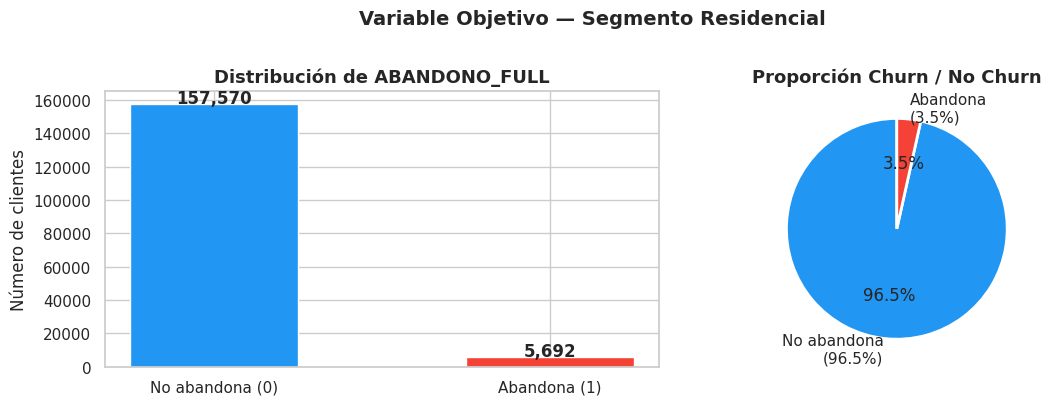

Tasa de churn: 3.49% — Dataset desbalanceado (se aplicará SMOTE en modelado)


In [ ]:
# ── Distribución de la variable objetivo ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo absoluto
counts = df['ABANDONO_FULL'].value_counts()
axes[0].bar(['No abandona (0)', 'Abandona (1)'], counts.values, color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución de ABANDONO_FULL', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de clientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Porcentaje
pcts = counts.values / len(df) * 100
axes[1].pie(pcts, labels=[f'No abandona\n({pcts[0]:.1f}%)', f'Abandona\n({pcts[1]:.1f}%)'],
            colors=['#2196F3', '#F44336'], startangle=90, autopct='%1.1f%%',
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporción Churn / No Churn', fontsize=13, fontweight='bold')

plt.suptitle('Variable Objetivo — Segmento Residencial', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_target_distribucion.png', bbox_inches='tight')
plt.show()
print(f"Tasa de churn: {pcts[1]:.2f}% — Dataset desbalanceado (se aplicará SMOTE en modelado)")


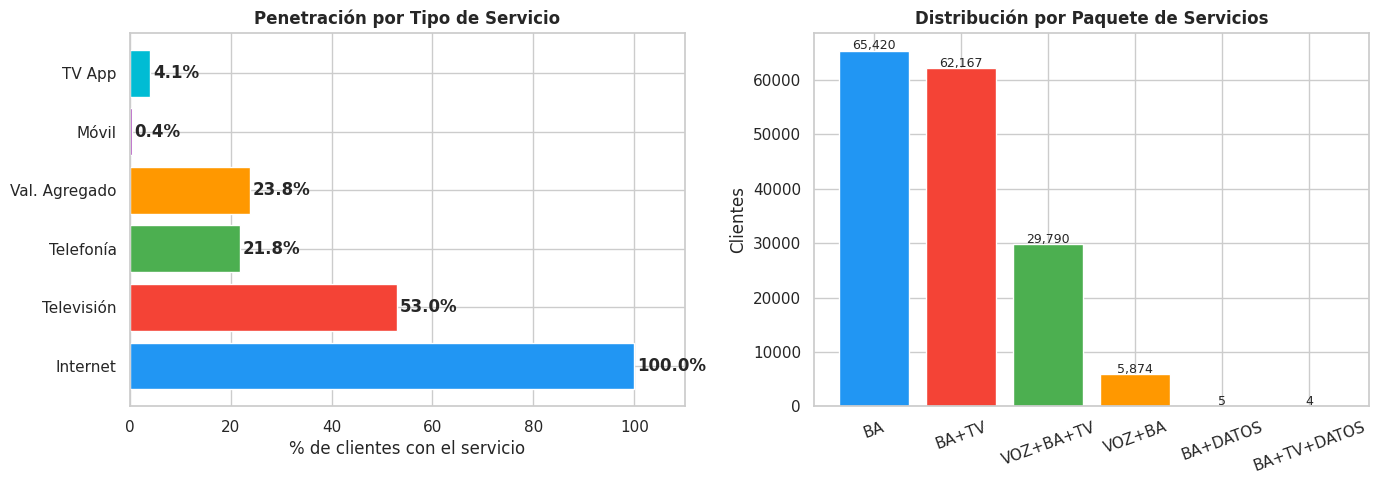

In [ ]:
# ── Análisis de servicios contratados ──
ss_cols = ['SS_INTE','SS_TV','SS_TEL','SS_SVA','SS_MOVIL','SS_TV_APP']
ss_labels = ['Internet','Televisión','Telefonía','Val. Agregado','Móvil','TV App']

penetracion = [(df[c] > 0).mean() * 100 for c in ss_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Penetración por servicio
bars = axes[0].barh(ss_labels, penetracion, color=COLORES, edgecolor='white')
axes[0].set_xlabel('% de clientes con el servicio')
axes[0].set_title('Penetración por Tipo de Servicio', fontweight='bold')
for bar, pct in zip(bars, penetracion):
    axes[0].text(pct + 0.5, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontweight='bold')
axes[0].set_xlim(0, 110)

# Distribución por paquete (CRUCE_ACTIVO)
top_paq = df['CRUCE_ACTIVO'].value_counts().head(6)
axes[1].bar(top_paq.index, top_paq.values, color=COLORES, edgecolor='white')
axes[1].set_title('Distribución por Paquete de Servicios', fontweight='bold')
axes[1].set_ylabel('Clientes')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(top_paq.values):
    axes[1].text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_servicios.png', bbox_inches='tight')
plt.show()


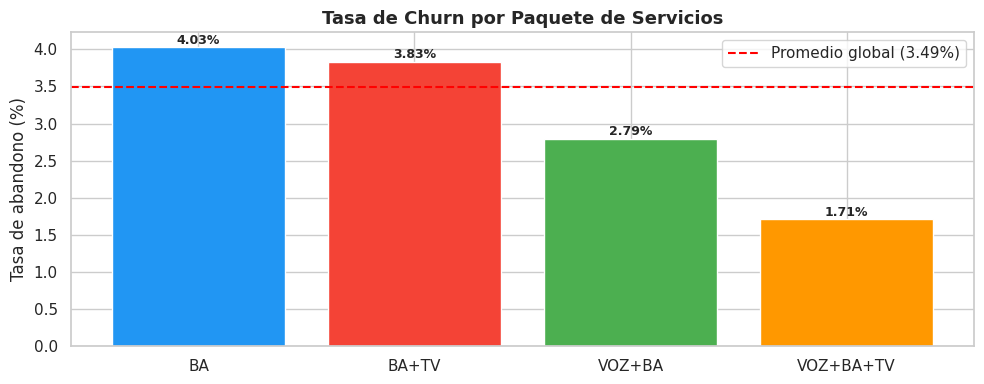

Observación: Los clientes con un solo servicio (BA) presentan la mayor tasa de churn,
lo que refuerza la hipótesis de que la multi-contratación actúa como ancla de fidelización.


In [ ]:
# ── Churn por paquete de servicios ──
churn_paq = df.groupby('CRUCE_ACTIVO')['ABANDONO_FULL'].agg(['mean','count']).reset_index()
churn_paq.columns = ['Paquete','Tasa_Churn','Clientes']
churn_paq = churn_paq[churn_paq['Clientes'] > 100].sort_values('Tasa_Churn', ascending=False)
churn_paq['Tasa_Churn_pct'] = churn_paq['Tasa_Churn'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(churn_paq['Paquete'], churn_paq['Tasa_Churn_pct'], color=COLORES, edgecolor='white')
ax.axhline(df['ABANDONO_FULL'].mean()*100, color='red', linestyle='--', label=f'Promedio global ({df["ABANDONO_FULL"].mean()*100:.2f}%)')
ax.set_title('Tasa de Churn por Paquete de Servicios', fontweight='bold', fontsize=13)
ax.set_ylabel('Tasa de abandono (%)')
ax.legend()
for bar, row in zip(bars, churn_paq.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row.Tasa_Churn_pct:.2f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_churn_paquete.png', bbox_inches='tight')
plt.show()

print("Observación: Los clientes con un solo servicio (BA) presentan la mayor tasa de churn,")
print("lo que refuerza la hipótesis de que la multi-contratación actúa como ancla de fidelización.")


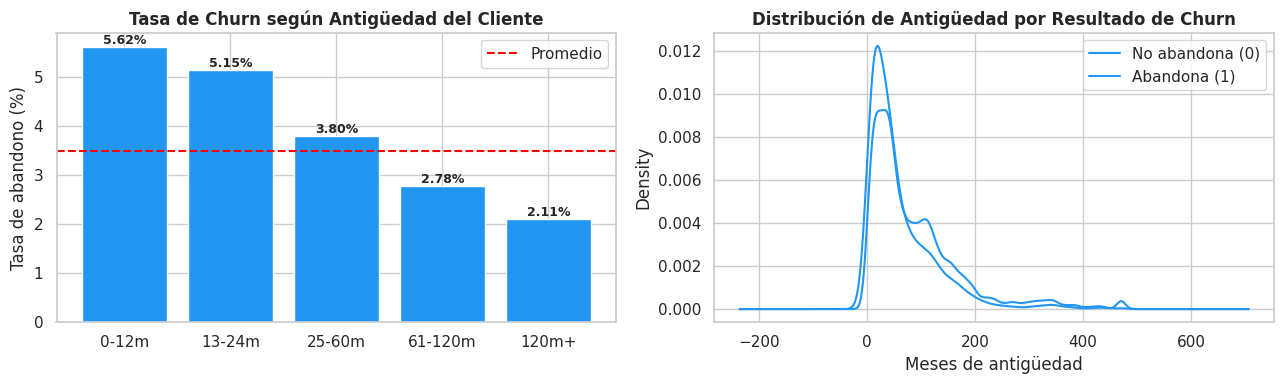

Los clientes más jóvenes (< 24 meses) presentan mayor tasa de abandono. H1 parcialmente validada.


In [ ]:
# ── Antigüedad vs Churn ──
df['segmento_antiguedad'] = pd.cut(df['ANTG_MESES_TODO'],
                                   bins=[0, 12, 24, 60, 120, 999],
                                   labels=['0-12m','13-24m','25-60m','61-120m','120m+'])
churn_ant = df.groupby('segmento_antiguedad', observed=True)['ABANDONO_FULL'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(churn_ant.index.astype(str), churn_ant.values, color='#2196F3', edgecolor='white')
axes[0].axhline(df['ABANDONO_FULL'].mean()*100, color='red', linestyle='--', label='Promedio')
axes[0].set_title('Tasa de Churn según Antigüedad del Cliente', fontweight='bold')
axes[0].set_ylabel('Tasa de abandono (%)')
axes[0].legend()
for i, v in enumerate(churn_ant.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

# Distribución de antigüedad por resultado
df.groupby('ABANDONO_FULL')['ANTG_MESES_TODO'].plot(kind='kde', ax=axes[1],
    label=['No abandona', 'Abandona'], color=['#2196F3', '#F44336'])
axes[1].set_title('Distribución de Antigüedad por Resultado de Churn', fontweight='bold')
axes[1].set_xlabel('Meses de antigüedad')
axes[1].legend(['No abandona (0)', 'Abandona (1)'])

plt.tight_layout()
plt.savefig('fig_antiguedad.png', bbox_inches='tight')
plt.show()
print("Los clientes más jóvenes (< 24 meses) presentan mayor tasa de abandono. H1 parcialmente validada.")


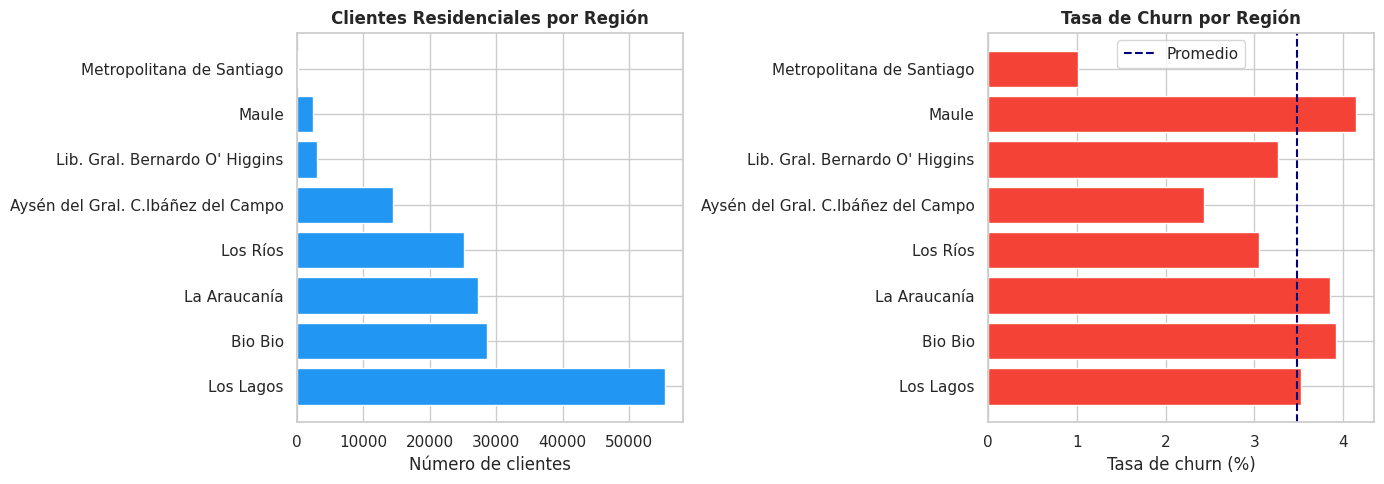

In [ ]:
# ── Distribución geográfica y churn por región ──
churn_region = df.groupby('REGION')['ABANDONO_FULL'].agg(['mean','count']).reset_index()
churn_region.columns = ['Region','Tasa_Churn','Clientes']
churn_region = churn_region.sort_values('Clientes', ascending=False)
churn_region['Tasa_pct'] = churn_region['Tasa_Churn'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clientes por región
axes[0].barh(churn_region['Region'], churn_region['Clientes'], color='#2196F3', edgecolor='white')
axes[0].set_title('Clientes Residenciales por Región', fontweight='bold')
axes[0].set_xlabel('Número de clientes')

# Churn por región
axes[1].barh(churn_region['Region'], churn_region['Tasa_pct'], color='#F44336', edgecolor='white')
axes[1].axvline(df['ABANDONO_FULL'].mean()*100, color='navy', linestyle='--', label='Promedio')
axes[1].set_title('Tasa de Churn por Región', fontweight='bold')
axes[1].set_xlabel('Tasa de churn (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_region.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── Valores nulos por columna ──
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
tabla_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': nulos_pct})
tabla_nulos = tabla_nulos[tabla_nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

print("Columnas con valores nulos:")
print(tabla_nulos.to_string())


Columnas con valores nulos:
                                         Nulos  % Nulos
TASA_TRANSM_EQUIPO_50                   163262   100.00
TASA_TRANSM_EQUIPO_24                   163262   100.00
RANK_EQUIPO                             163262   100.00
LISTA_EQUIPOS                           163262   100.00
FECHA_CONTACTO                          163247    99.99
LISTA_CAUSAS_COMERCIAL_NO_TERRENO       157997    96.78
LISTA_CAUSAS_TECNICO_TERRENO            134239    82.22
LISTA_TIPO_RECLAMOS_TECNICO_TERRENO     134239    82.22
LISTA_TIPO_RECLAMOS_TECNICO_NO_TERRENO  126189    77.29
LISTA_CAUSAS_TECNICO_NO_TERRENO         126189    77.29
LISTA_SS_SVA                            124385    76.19
MES_RECLAMO_MAX                         106719    65.37
NUM_RECLAMOS_TECNICO_TERRENO            106719    65.37
MES_RECLAMO_MIN                         106719    65.37
NUM_RECLAMOS                            106719    65.37
CODIGO_INE_COMUNA                         7054     4.32
PROVINCIA           

---
<a id='fase3'></a>
## Fase 3 — Preparación de los Datos (Data Preparation)

### 3.1 Estrategia de Selección de Variables

Se excluyen:
- Identificadores (RUT_CLIENTE, NOMB_RAZON, FECHA, FECH_ALTA, FECHA_MIN, FECHA_CONTACTO)
- Columnas ABA_* (contienen información futura, no disponible en tiempo real)
- Columnas con más del 90% de nulos (TASA_TRANSM_EQUIPO_24, TASA_TRANSM_EQUIPO_50, RANK_EQUIPO, LISTA_EQUIPOS)
- Columnas con texto libre (LISTA_SS_SVA, LISTA_CAUSAS_*, LISTA_TIPO_*)
- Otras variables objetivo ABANDONO_* distintas al target

### 3.2 Tratamiento de Valores Faltantes

- `NUM_RECLAMOS` y `NUM_RECLAMOS_TECNICO_TERRENO`: el nulo indica ausencia de reclamos → se imputa con 0
- `VELOCIDAD_SUBIDA` / `VELOCIDAD_BAJADA`: se imputa con la mediana
- `CODIGO_INE_COMUNA`, lat/long: se excluyen (alta proporción nula, redundante con REGION/COMUNA)


In [ ]:
# ── Selección de features ──
FEATURES = [
    # Servicios contratados
    'SS_INTE','SS_TV','SS_TEL','SS_SVA','SS_MOVIL','SS_TV_APP',
    # Características del cliente
    'ANTG_MESES_TODO','VLOR_NETO_PROM','MONTO_POR_SS','MESES_COBROS',
    'LOCALIDADES_DISTINTAS','NUM_IDEN_GRUPOFAC',
    # Velocidad de Internet
    'VELOCIDAD_BAJADA','VELOCIDAD_SUBIDA',
    # Reclamos (NaN → 0 porque indica sin reclamos)
    'NUM_RECLAMOS','NUM_RECLAMOS_TECNICO_TERRENO','EVENTOS_DISTINTOS','HORAS_TOTALES_RUT',
    # Servicios adicionales vigentes (binarios)
    'FOX_SPORT_VIGENTE','OFFICE_VIGENTE','PLAN_HBO_VIGENTE',
    'PROVEEDOR_FINAL_ALARMCOM_VIGENTE','TNT_SPORT_VIGENTE','TELEVIGILANCIA',
    # Flags cliente
    'CONDICION_ESPECIAL','PRIORITARIO',
]

TARGET = 'ABANDONO_FULL'

df_model = df[FEATURES + [TARGET]].copy()
print(f"Shape inicial: {df_model.shape}")
print(f"Distribución target: {df_model[TARGET].value_counts().to_dict()}")


Shape inicial: (163262, 27)
Distribución target: {0: 157570, 1: 5692}


In [ ]:
# ── Imputación de valores nulos ──

# Reclamos: NaN = sin reclamos → 0
for col in ['NUM_RECLAMOS','NUM_RECLAMOS_TECNICO_TERRENO']:
    df_model[col] = df_model[col].fillna(0)

# Velocidad: mediana
for col in ['VELOCIDAD_BAJADA','VELOCIDAD_SUBIDA']:
    mediana = df_model[col].median()
    df_model[col] = df_model[col].fillna(mediana)
    print(f"  {col} → imputado con mediana = {mediana}")

# Codificación de variables categóricas binarias (S/N → 1/0)
for col in ['CONDICION_ESPECIAL','PRIORITARIO']:
    df_model[col] = df_model[col].map({'S': 1, 'N': 0}).fillna(0)

# TELEVIGILANCIA es numérico (0/1), verificar
df_model['TELEVIGILANCIA'] = pd.to_numeric(df_model['TELEVIGILANCIA'], errors='coerce').fillna(0)

print(f"\nNulos restantes: {df_model.isnull().sum().sum()}")
print(f"Shape final: {df_model.shape}")


  VELOCIDAD_BAJADA → imputado con mediana = 900.0
  VELOCIDAD_SUBIDA → imputado con mediana = 600.0

Nulos restantes: 0
Shape final: (163262, 27)


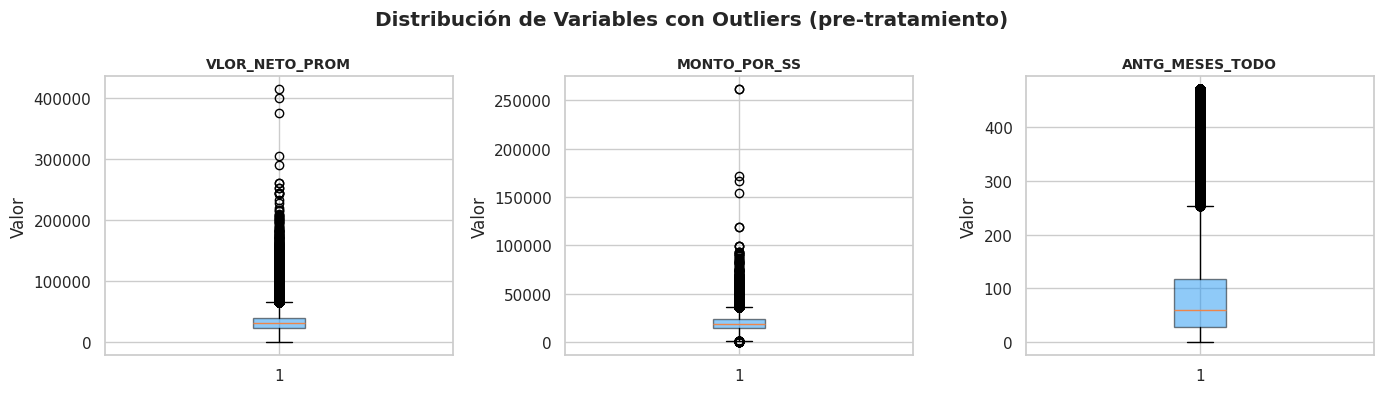

  VLOR_NETO_PROM: 1633 valores capados al percentil 99 (89,605)
  MONTO_POR_SS: 1633 valores capados al percentil 99 (39,320)
  ANTG_MESES_TODO: 1621 valores capados al percentil 99 (425)

Winsorización aplicada. No se eliminaron filas — se preserva el máximo de información.


In [ ]:
# ── Detección y tratamiento de outliers ──
# Se usa IQR sobre variables de valor/facturación
cols_outlier = ['VLOR_NETO_PROM','MONTO_POR_SS','ANTG_MESES_TODO']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cols_outlier):
    ax.boxplot(df_model[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#2196F3', alpha=0.5))
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel('Valor')

plt.suptitle('Distribución de Variables con Outliers (pre-tratamiento)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_outliers.png', bbox_inches='tight')
plt.show()

# Estrategia: Winsorización al percentil 99 (no se eliminan filas, se capa el valor)
for col in cols_outlier:
    p99 = df_model[col].quantile(0.99)
    n_outlier = (df_model[col] > p99).sum()
    df_model[col] = df_model[col].clip(upper=p99)
    print(f"  {col}: {n_outlier} valores capados al percentil 99 ({p99:,.0f})")

print("\nWinsorización aplicada. No se eliminaron filas — se preserva el máximo de información.")


In [ ]:
# ── Split train / test ──
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} registros | Test: {X_test.shape[0]:,} registros")
print(f"Tasa churn train: {y_train.mean()*100:.2f}% | test: {y_test.mean()*100:.2f}%")

# ── Balanceo con SMOTE (solo sobre train) ──
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nTrain balanceado con SMOTE: {X_train_bal.shape[0]:,} registros")
print(f"Distribución: {pd.Series(y_train_bal).value_counts().to_dict()}")


Train: 130,609 registros | Test: 32,653 registros
Tasa churn train: 3.49% | test: 3.49%



Train balanceado con SMOTE: 252,110 registros
Distribución: {0: 126055, 1: 126055}


In [ ]:
# ── Escalado ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

print("Escalado StandardScaler aplicado.")


Escalado StandardScaler aplicado.


---
<a id='fase4'></a>
## Fase 4 — Modelado

Se implementan **tres modelos supervisados** para predecir ABANDONO_FULL:

| # | Modelo | Fundamento |
|---|--------|-----------|
| 1 | Regresión Logística | Modelo lineal probabilístico; alta interpretabilidad; coeficientes directamente traducibles a factores de riesgo |
| 2 | Árbol de Decisión | Captura relaciones no lineales; genera reglas de negocio legibles; útil para explicar decisiones al área comercial |
| 3 | Naive Bayes (Gaussiano) | Modelo investigado; asume independencia entre variables; eficiente en datasets grandes; sirve de baseline probabilístico |

La variable objetivo es **ABANDONO_FULL** (abandono completo del cliente).


In [ ]:
# ── Definición y entrenamiento de modelos ──

modelos = {
    'Regresión Logística': LogisticRegression(
        max_iter=1000, class_weight='balanced', C=0.5, random_state=42
    ),
    'Árbol de Decisión': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=50, class_weight='balanced', random_state=42
    ),
    'Naive Bayes': GaussianNB(var_smoothing=1e-8)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_sc, y_train_bal)
    y_pred   = modelo.predict(X_test_sc)
    y_proba  = modelo.predict_proba(X_test_sc)[:, 1]

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    f1    = f1_score(y_test, y_pred, zero_division=0)
    auc   = roc_auc_score(y_test, y_proba)

    resultados[nombre] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'ROC-AUC': auc,
        'y_pred': y_pred, 'y_proba': y_proba
    }
    print(f"[{nombre}] AUC={auc:.4f} | Acc={acc:.4f} | Rec={rec:.4f} | Prec={prec:.4f} | F1={f1:.4f}")


[Regresión Logística] AUC=0.5899 | Acc=0.5661 | Rec=0.5615 | Prec=0.0447 | F1=0.0827


[Árbol de Decisión] AUC=0.5640 | Acc=0.6739 | Rec=0.4253 | Prec=0.0462 | F1=0.0833
[Naive Bayes] AUC=0.5601 | Acc=0.1659 | Rec=0.9605 | Prec=0.0386 | F1=0.0743


---
<a id='fase5'></a>
## Fase 5 — Evaluación de Modelos

### 5.1 Perspectiva de Negocio sobre los Errores

En un problema de churn en telecomunicaciones, los costos de los errores no son simétricos:

- **Falso Positivo (FP):** Se ofrece una campaña de retención a un cliente que no se iba a ir. Costo: el valor de la oferta (descuento, gift card, etc.). Costo bajo y recuperable.
- **Falso Negativo (FN):** No se detecta a un cliente que sí abandona. Costo: pérdida total del ingreso recurrente del cliente (LTV). Costo alto e irrecuperable.

**Conclusión:** En este contexto, el **Recall** (sensibilidad) es la métrica más crítica. Preferimos capturar el mayor número posible de clientes en riesgo, aunque eso implique activar campañas sobre algunos que no se iban. La curva **ROC-AUC** complementa esto evaluando la capacidad discriminante global del modelo.


In [ ]:
# ── Tabla comparativa de métricas ──
metricas_df = pd.DataFrame({
    nombre: {k: v for k, v in res.items() if k not in ('y_pred','y_proba')}
    for nombre, res in resultados.items()
}).T.round(4)

print("Tabla comparativa de métricas:")
print(metricas_df.to_string())


Tabla comparativa de métricas:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Regresión Logística    0.5661     0.0447  0.5615    0.0827   0.5899
Árbol de Decisión      0.6739     0.0462  0.4253    0.0833   0.5640
Naive Bayes            0.1659     0.0386  0.9605    0.0743   0.5601


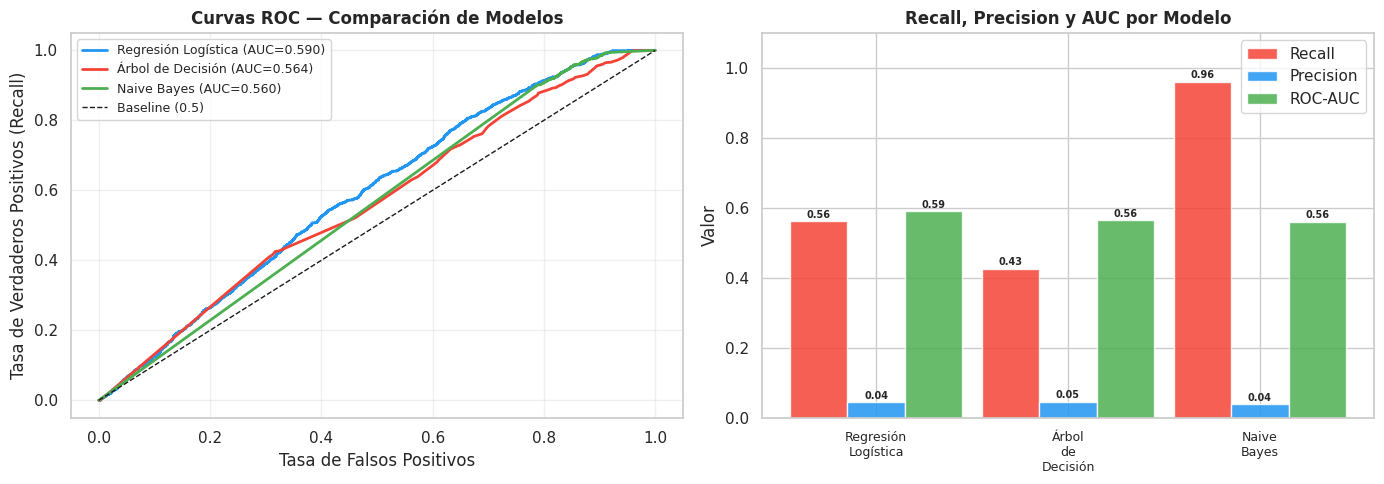

In [ ]:
# ── Visualización: curvas ROC ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for (nombre, res), color in zip(resultados.items(), COLORES):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{nombre} (AUC={res['ROC-AUC']:.3f})", color=color, lw=2)
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Baseline (0.5)')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].set_title('Curvas ROC — Comparación de Modelos', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Barras: Recall vs Precision por modelo
nombres_mod = list(resultados.keys())
recalls  = [resultados[n]['Recall'] for n in nombres_mod]
precisions = [resultados[n]['Precision'] for n in nombres_mod]
aucs     = [resultados[n]['ROC-AUC'] for n in nombres_mod]

x = np.arange(len(nombres_mod))
w = 0.3
axes[1].bar(x - w, recalls,    w, label='Recall',    color='#F44336', alpha=0.85, edgecolor='white')
axes[1].bar(x,     precisions, w, label='Precision',  color='#2196F3', alpha=0.85, edgecolor='white')
axes[1].bar(x + w, aucs,       w, label='ROC-AUC',   color='#4CAF50', alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(' ', '\n') for n in nombres_mod], fontsize=9)
axes[1].set_title('Recall, Precision y AUC por Modelo', fontweight='bold')
axes[1].set_ylabel('Valor')
axes[1].legend()
axes[1].set_ylim(0, 1.1)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_roc_comparativo.png', bbox_inches='tight')
plt.show()


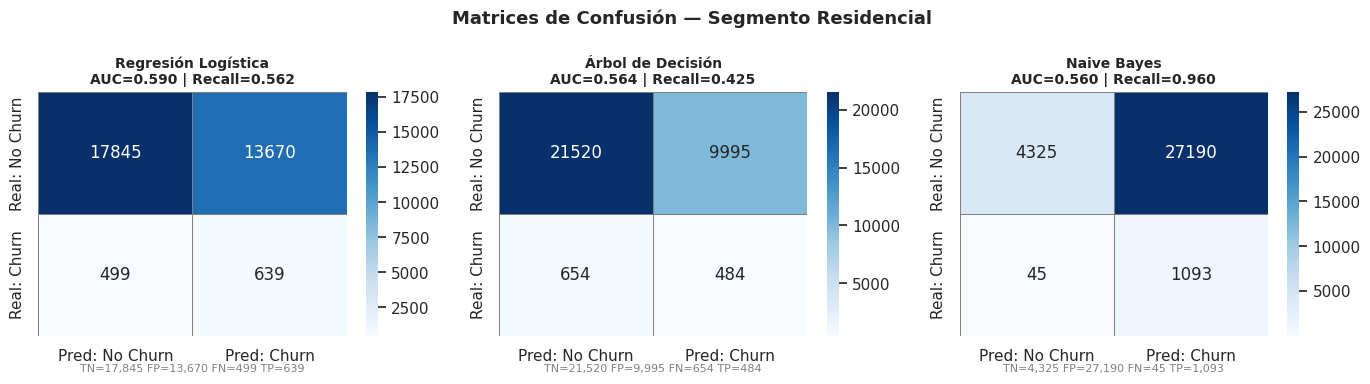

In [ ]:
# ── Matrices de confusión ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Pred: No Churn','Pred: Churn'],
                yticklabels=['Real: No Churn','Real: Churn'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'{nombre}\nAUC={res["ROC-AUC"]:.3f} | Recall={res["Recall"]:.3f}',
                 fontweight='bold', fontsize=10)

    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.15, f'TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}',
            transform=ax.transAxes, ha='center', fontsize=8, color='gray')

plt.suptitle('Matrices de Confusión — Segmento Residencial', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── Validación cruzada del mejor modelo ──
# Determinar modelo ganador por ROC-AUC
mejor_nombre = max(resultados, key=lambda n: resultados[n]['ROC-AUC'])
mejor_modelo  = modelos[mejor_nombre]
print(f"Modelo ganador: {mejor_nombre} | AUC = {resultados[mejor_nombre]['ROC-AUC']:.4f}")

cv_scores = cross_val_score(mejor_modelo, X_train_sc, y_train_bal,
                             cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='roc_auc')
print(f"AUC en validación cruzada (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Modelo ganador: Regresión Logística | AUC = 0.5899


AUC en validación cruzada (5-fold): 0.7449 ± 0.0017


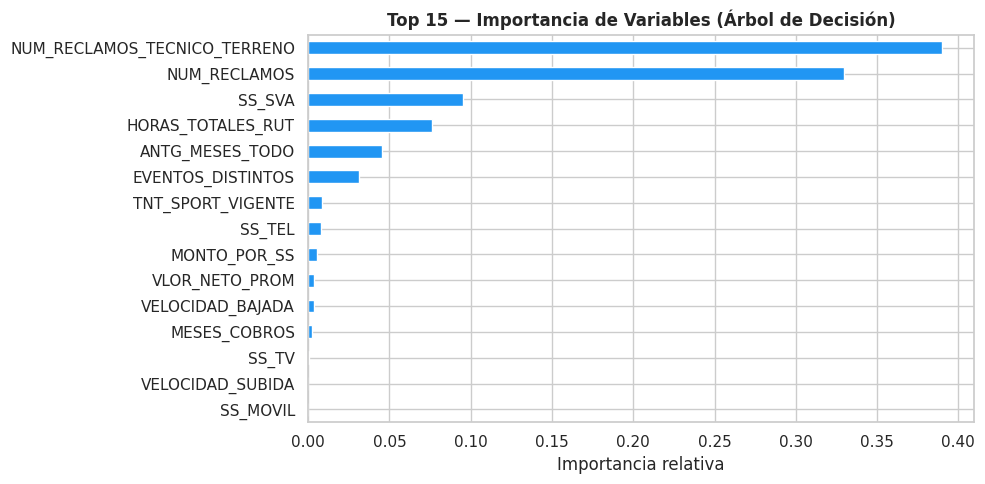

Las variables con mayor peso predictivo son las que se deben priorizar en campañas de retención.


In [ ]:
# ── Importancia de variables (Árbol de Decisión) ──
dt = modelos['Árbol de Decisión']
importancias = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importancias.head(15).plot(kind='barh', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title('Top 15 — Importancia de Variables (Árbol de Decisión)', fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_importancia_variables.png', bbox_inches='tight')
plt.show()
print("Las variables con mayor peso predictivo son las que se deben priorizar en campañas de retención.")


In [ ]:
# ── Clasificación detallada del modelo ganador ──
print(f"\n=== Reporte Clasificación: {mejor_nombre} ===")
print(classification_report(y_test, resultados[mejor_nombre]['y_pred'],
                              target_names=['No Abandona','Abandona']))



=== Reporte Clasificación: Regresión Logística ===
              precision    recall  f1-score   support

 No Abandona       0.97      0.57      0.72     31515
    Abandona       0.04      0.56      0.08      1138

    accuracy                           0.57     32653
   macro avg       0.51      0.56      0.40     32653
weighted avg       0.94      0.57      0.69     32653



---
<a id='apriori'></a>
## Reglas de Asociación — Algoritmo Apriori

El algoritmo Apriori se aplica para descubrir patrones de contratación conjunta de servicios. El objetivo es identificar qué combinaciones de servicios aparecen juntas con frecuencia, lo que permite definir estrategias de cross-selling y anclas de fidelización.

**Métricas clave:**
- **Soporte**: proporción de clientes que tienen el itemset
- **Confianza**: probabilidad de que dado A, el cliente también tenga B  
- **Lift**: cuánto más probable es B dado A, versus la probabilidad base de B (Lift > 1 indica asociación positiva real)


In [ ]:
# ── Preparación de transacciones para Apriori ──
# Crear columnas binarias por servicio (1 si tiene el servicio, 0 si no)
servicios_bin = {
    'Internet': (df['SS_INTE'] > 0).astype(int),
    'Television': (df['SS_TV'] > 0).astype(int),
    'Telefonia': (df['SS_TEL'] > 0).astype(int),
    'Val_Agregado': (df['SS_SVA'] > 0).astype(int),
    'Movil': (df['SS_MOVIL'] > 0).astype(int),
    'TV_App': (df['SS_TV_APP'] > 0).astype(int),
    'Fox_Sport': (df['FOX_SPORT_VIGENTE'] > 0).astype(int),
    'HBO': (df['PLAN_HBO_VIGENTE'] > 0).astype(int),
    'Office': (df['OFFICE_VIGENTE'] > 0).astype(int),
    'TNT_Sport': (df['TNT_SPORT_VIGENTE'] > 0).astype(int),
    'Condicion_Especial': (df['CONDICION_ESPECIAL'] == 'S').astype(int),
    'Prioritario': (df['PRIORITARIO'] == 'S').astype(int),
}

df_trans = pd.DataFrame(servicios_bin).astype(bool)
print(f"Transacciones preparadas: {df_trans.shape[0]:,} clientes x {df_trans.shape[1]} items")
print("\nFrecuencia de cada ítem:")
print((df_trans.mean() * 100).round(2).sort_values(ascending=False).to_string())


Transacciones preparadas: 163,262 clientes x 12 items

Frecuencia de cada ítem:
Internet              100.00
Television             52.97
Val_Agregado           23.81
Telefonia              21.85
TNT_Sport               5.98
TV_App                  4.12
Office                  0.44
Movil                   0.38
HBO                     0.30
Fox_Sport               0.16
Prioritario             0.06
Condicion_Especial      0.00


In [ ]:
# ── Aplicación del algoritmo Apriori ──
itemsets_frecuentes = apriori(df_trans, min_support=0.05, use_colnames=True, max_len=3)
print(f"Itemsets frecuentes encontrados: {len(itemsets_frecuentes)}")
print(itemsets_frecuentes.sort_values('support', ascending=False).head(10).to_string())


Itemsets frecuentes encontrados: 18
     support                                      itemsets
0   1.000000                         frozenset({Internet})
1   0.529658                       frozenset({Television})
5   0.529658             frozenset({Television, Internet})
3   0.238126                     frozenset({Val_Agregado})
7   0.238126           frozenset({Val_Agregado, Internet})
2   0.218459                        frozenset({Telefonia})
6   0.218459              frozenset({Telefonia, Internet})
9   0.180262            frozenset({Television, Telefonia})
13  0.180262  frozenset({Television, Telefonia, Internet})
10  0.157452         frozenset({Television, Val_Agregado})


In [ ]:
# ── Generación de reglas de asociación ──
reglas = association_rules(itemsets_frecuentes, metric='lift', min_threshold=1.2, num_itemsets=len(itemsets_frecuentes))
reglas = reglas.sort_values('lift', ascending=False)

print(f"Reglas generadas: {len(reglas)}")
print("\n=== Top 15 Reglas por Lift ===")
print(reglas[['antecedents','consequents','support','confidence','lift']].head(15).to_string())


Reglas generadas: 30

=== Top 15 Reglas por Lift ===
                              antecedents                            consequents   support  confidence      lift
5                  frozenset({TNT_Sport})                frozenset({Television})  0.057852    0.968023  1.827638
17       frozenset({TNT_Sport, Internet})                frozenset({Television})  0.057852    0.968023  1.827638
19                 frozenset({TNT_Sport})      frozenset({Television, Internet})  0.057852    0.968023  1.827638
18                frozenset({Television})       frozenset({TNT_Sport, Internet})  0.057852    0.109225  1.827638
16      frozenset({Television, Internet})                 frozenset({TNT_Sport})  0.057852    0.109225  1.827638
4                 frozenset({Television})                 frozenset({TNT_Sport})  0.057852    0.109225  1.827638
27                frozenset({Television})   frozenset({Val_Agregado, Telefonia})  0.053962    0.101882  1.574683
26   frozenset({Val_Agregado, Telefonia})  

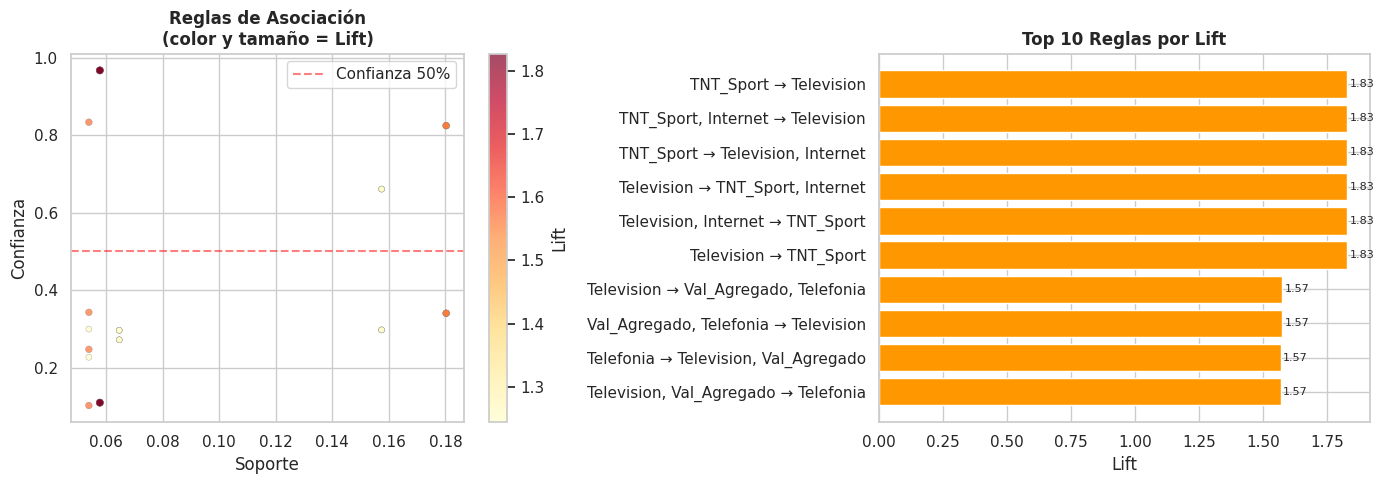

In [ ]:
# ── Visualización de reglas de asociación ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: soporte vs confianza, tamaño = lift
scatter = axes[0].scatter(
    reglas['support'], reglas['confidence'],
    c=reglas['lift'], cmap='YlOrRd', s=reglas['lift']*15, alpha=0.7, edgecolors='gray', linewidths=0.3
)
plt.colorbar(scatter, ax=axes[0], label='Lift')
axes[0].set_xlabel('Soporte')
axes[0].set_ylabel('Confianza')
axes[0].set_title('Reglas de Asociación\n(color y tamaño = Lift)', fontweight='bold')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Confianza 50%')
axes[0].legend()

# Top 10 reglas por lift (barras)
top_reglas = reglas.head(10).copy()
top_reglas['regla'] = top_reglas['antecedents'].astype(str).str.replace("frozenset\(|\)|{|}|'", '', regex=True) +                       ' → ' + top_reglas['consequents'].astype(str).str.replace("frozenset\(|\)|{|}|'", '', regex=True)
top_reglas['regla'] = top_reglas['regla'].str[:40]

bars = axes[1].barh(top_reglas['regla'], top_reglas['lift'], color='#FF9800', edgecolor='white')
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 10 Reglas por Lift', fontweight='bold')
axes[1].invert_yaxis()
for bar, v in zip(bars, top_reglas['lift']):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_apriori.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── Interpretación: reglas ancla de fidelización ──
# Filtrar reglas relevantes para retención (con Internet como consecuente o antecedente)
reglas_internet = reglas[
    reglas['antecedents'].apply(lambda x: 'Internet' in x) |
    reglas['consequents'].apply(lambda x: 'Internet' in x)
].head(10)

print("=== Reglas que involucran Internet (servicio ancla) ===")
print(reglas_internet[['antecedents','consequents','support','confidence','lift']].to_string())
print()
print("Interpretación de negocio:")
print("  Si un cliente tiene Internet + Televisión, la confianza de retener Internet es alta.")
print("  Esto sugiere que TV actúa como ancla de fidelización para clientes con riesgo de churn en Internet.")


=== Reglas que involucran Internet (servicio ancla) ===
                            antecedents                        consequents   support  confidence      lift
17     frozenset({TNT_Sport, Internet})            frozenset({Television})  0.057852    0.968023  1.827638
19               frozenset({TNT_Sport})  frozenset({Television, Internet})  0.057852    0.968023  1.827638
18              frozenset({Television})   frozenset({TNT_Sport, Internet})  0.057852    0.109225  1.827638
16    frozenset({Television, Internet})             frozenset({TNT_Sport})  0.057852    0.109225  1.827638
8     frozenset({Television, Internet})             frozenset({Telefonia})  0.180262    0.340337  1.557903
9      frozenset({Telefonia, Internet})            frozenset({Television})  0.180262    0.825156  1.557903
10              frozenset({Television})   frozenset({Telefonia, Internet})  0.180262    0.340337  1.557903
11               frozenset({Telefonia})  frozenset({Television, Internet})  0.180262    

---
<a id='clustering'></a>
## Segmentación No Supervisada

### 7.1 Objetivo

Identificar grupos homogéneos de clientes residenciales según sus características de contratación, antigüedad y valor, para diseñar campañas de retención personalizadas por segmento.

### 7.2 Variables utilizadas para clustering

Se usan variables que caracterizan el perfil del cliente y no contienen información futura.


In [ ]:
# ── Preparación de features para clustering ──
FEATURES_CLUSTER = [
    'SS_INTE','SS_TV','SS_TEL','SS_SVA','SS_MOVIL',
    'ANTG_MESES_TODO','VLOR_NETO_PROM','NUM_RECLAMOS',
    'EVENTOS_DISTINTOS','TELEVIGILANCIA'
]

df_cluster = df_model[FEATURES_CLUSTER].fillna(0).copy()

scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(df_cluster)

# Muestra para clustering (80k para eficiencia computacional)
np.random.seed(42)
idx = np.random.choice(len(X_cl), size=min(80000, len(X_cl)), replace=False)
X_cl_sample = X_cl[idx]
y_sample = y_test.values if len(y_test) == len(X_cl) else df_model[TARGET].values[idx]
y_churn_sample = df_model[TARGET].values[idx]

print(f"Muestra para clustering: {len(X_cl_sample):,} registros")


Muestra para clustering: 80,000 registros


  K=2 | Inercia=578,660 | Silhouette=0.3486


  K=3 | Inercia=508,662 | Silhouette=0.2554


  K=4 | Inercia=444,385 | Silhouette=0.2750


  K=5 | Inercia=387,023 | Silhouette=0.2906


  K=6 | Inercia=349,321 | Silhouette=0.2994


  K=7 | Inercia=316,017 | Silhouette=0.3090


  K=8 | Inercia=288,649 | Silhouette=0.3206


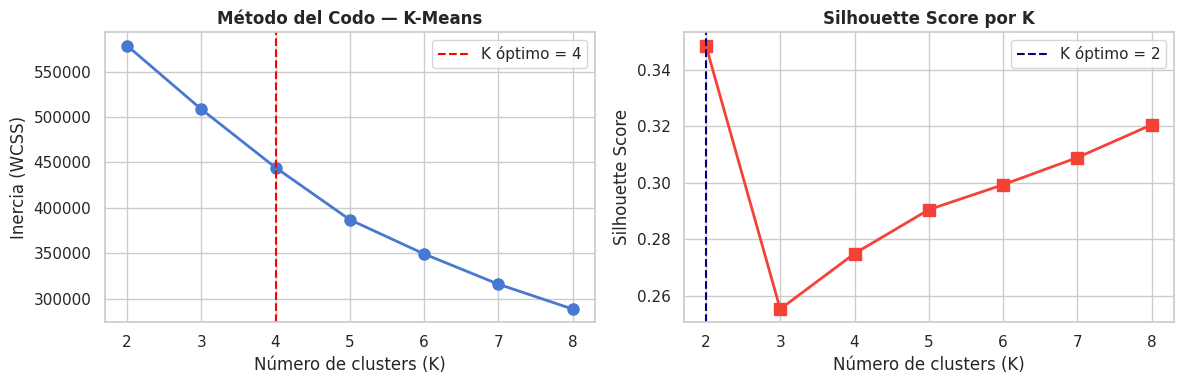

In [ ]:
# ── Método del Codo para K-Means ──
inercias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl_sample)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_cl_sample, km.labels_, sample_size=5000, random_state=42)
    silhouette_scores.append(sil)
    print(f"  K={k} | Inercia={km.inertia_:,.0f} | Silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inercias, 'bo-', markersize=8, lw=2)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo — K-Means', fontweight='bold')
axes[0].axvline(4, color='red', linestyle='--', label='K óptimo = 4')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, 'rs-', markersize=8, lw=2, color='#F44336')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K', fontweight='bold')
axes[1].axvline(silhouette_scores.index(max(silhouette_scores)) + 2, color='navy', linestyle='--',
                label=f'K óptimo = {silhouette_scores.index(max(silhouette_scores)) + 2}')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_codo.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── K-Means con K óptimo ──
K_OPTIMO = 4
km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
labels_km = km_final.fit_predict(X_cl_sample)

sil_final = silhouette_score(X_cl_sample, labels_km, sample_size=10000, random_state=42)
db_final  = davies_bouldin_score(X_cl_sample[:10000], labels_km[:10000])

print(f"K-Means K={K_OPTIMO}")
print(f"  Silhouette Score: {sil_final:.4f}")
print(f"  Davies-Bouldin:   {db_final:.4f}")
print(f"  (Silhouette cercano a 1 es óptimo; DB cercano a 0 es óptimo)")
print()
print("Distribución de clientes por cluster:")
from collections import Counter
print(Counter(labels_km))


K-Means K=4
  Silhouette Score: 0.2766
  Davies-Bouldin:   1.4252
  (Silhouette cercano a 1 es óptimo; DB cercano a 0 es óptimo)

Distribución de clientes por cluster:
Counter({np.int32(0): 33463, np.int32(2): 26615, np.int32(3): 15776, np.int32(1): 4146})


In [ ]:
# ── Perfilado de clusters ──
df_cl_result = pd.DataFrame(X_cl_sample, columns=FEATURES_CLUSTER)
df_cl_result['Cluster'] = labels_km
df_cl_result['ABANDONO_FULL'] = y_churn_sample

# Promedio de cada feature por cluster (en escala original)
df_orig_sample = df_cluster.iloc[idx].copy()
df_orig_sample['Cluster'] = labels_km
df_orig_sample['ABANDONO_FULL'] = y_churn_sample

perfil = df_orig_sample.groupby('Cluster').agg(
    Clientes=('ABANDONO_FULL', 'count'),
    Tasa_Churn=('ABANDONO_FULL', 'mean'),
    Antiguedad=('ANTG_MESES_TODO', 'mean'),
    Valor_Neto=('VLOR_NETO_PROM', 'mean'),
    Servicios_Internet=('SS_INTE', 'mean'),
    Servicios_TV=('SS_TV', 'mean'),
    Servicios_Tel=('SS_TEL', 'mean'),
    Reclamos=('NUM_RECLAMOS', 'mean'),
    Eventos_Falla=('EVENTOS_DISTINTOS', 'mean'),
).round(3)

perfil['Tasa_Churn_pct'] = (perfil['Tasa_Churn'] * 100).round(2)
print(perfil.to_string())


         Clientes  Tasa_Churn  Antiguedad  Valor_Neto  Servicios_Internet  Servicios_TV  Servicios_Tel  Reclamos  Eventos_Falla  Tasa_Churn_pct
Cluster                                                                                                                                        
0           33463       0.043      47.505   23587.222               1.004         0.000          0.007     0.402          1.084             4.3
1            4146       0.018     125.450   62658.537               2.126         1.036          0.433     1.101          1.214             1.8
2           26615       0.035      71.661   37940.403               1.000         0.995          0.000     0.674          1.132             3.5
3           15776       0.020     182.883   40810.977               1.001         0.839          1.011     0.802          1.122             2.0


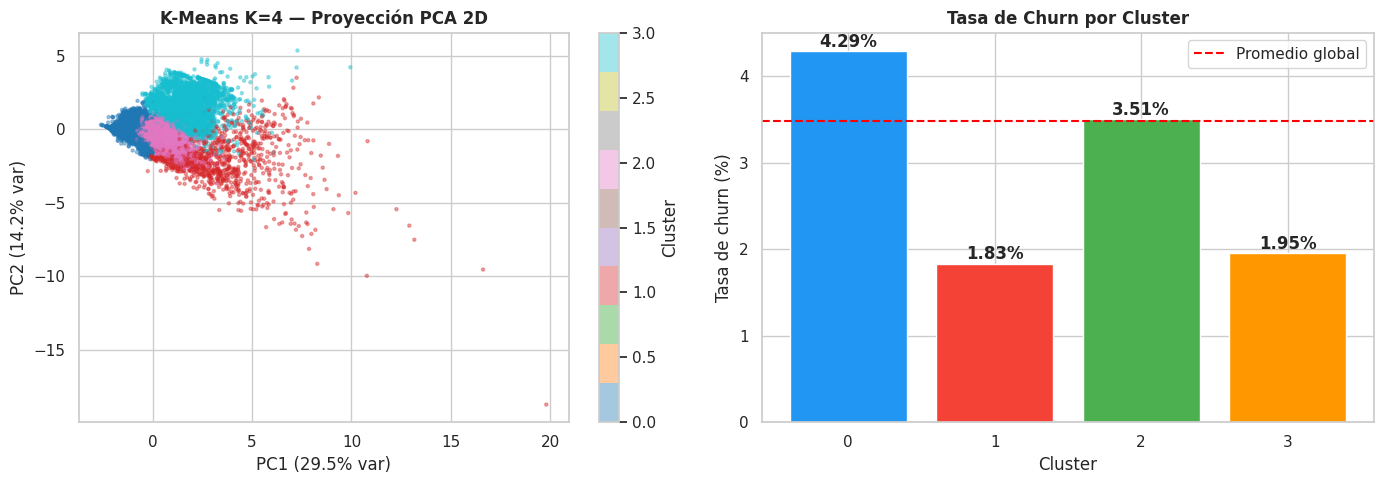

In [ ]:
# ── Visualización de clusters ──
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl_sample[:20000])
labels_pca = labels_km[:20000]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter por cluster
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca,
                          cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter, ax=axes[0], label='Cluster')
axes[0].set_title(f'K-Means K={K_OPTIMO} — Proyección PCA 2D', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')

# Tasa de churn por cluster
churn_cluster = df_orig_sample.groupby('Cluster')['ABANDONO_FULL'].mean() * 100
colors_cl = [COLORES[i] for i in range(K_OPTIMO)]
bars = axes[1].bar(churn_cluster.index.astype(str), churn_cluster.values, color=colors_cl, edgecolor='white')
axes[1].axhline(df['ABANDONO_FULL'].mean()*100, color='red', linestyle='--', label=f'Promedio global')
axes[1].set_title('Tasa de Churn por Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Tasa de churn (%)')
axes[1].legend()
for bar, v in zip(bars, churn_cluster.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_clusters.png', bbox_inches='tight')
plt.show()


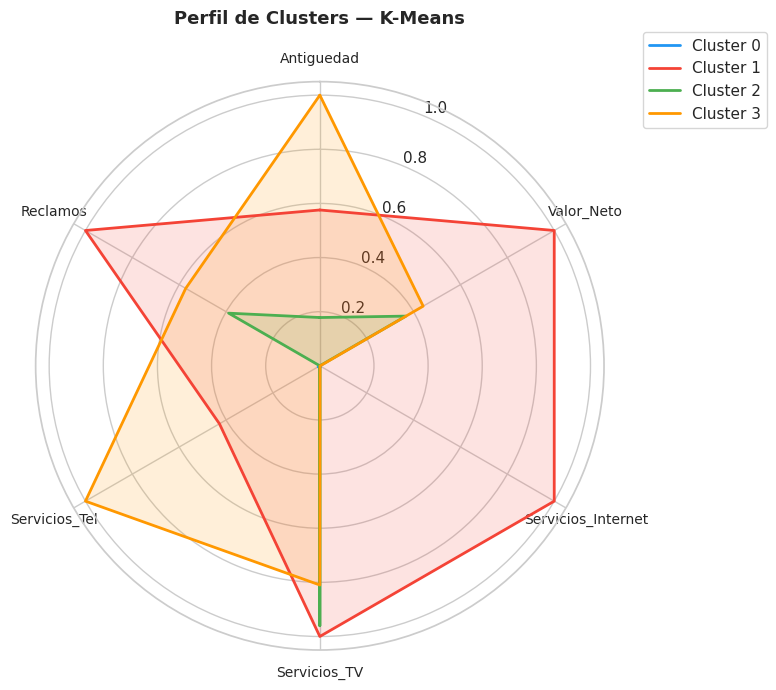

In [ ]:
# ── Radar chart de perfil de clusters ──
from matplotlib.patches import FancyArrowPatch

# Normalizar promedios para radar
cols_radar = ['Antiguedad','Valor_Neto','Servicios_Internet','Servicios_TV','Servicios_Tel','Reclamos']
perfil_norm = perfil[cols_radar].copy()
for c in cols_radar:
    rng = perfil_norm[c].max() - perfil_norm[c].min()
    if rng > 0:
        perfil_norm[c] = (perfil_norm[c] - perfil_norm[c].min()) / rng

categorias = cols_radar
N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angulos[:-1], categorias, size=10)

nombres_cluster = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}
for i, row in perfil_norm.iterrows():
    valores = row[cols_radar].values.tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, lw=2, color=COLORES[i], label=nombres_cluster[i])
    ax.fill(angulos, valores, alpha=0.15, color=COLORES[i])

ax.set_title('Perfil de Clusters — K-Means', fontweight='bold', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('fig_radar_clusters.png', bbox_inches='tight')
plt.show()


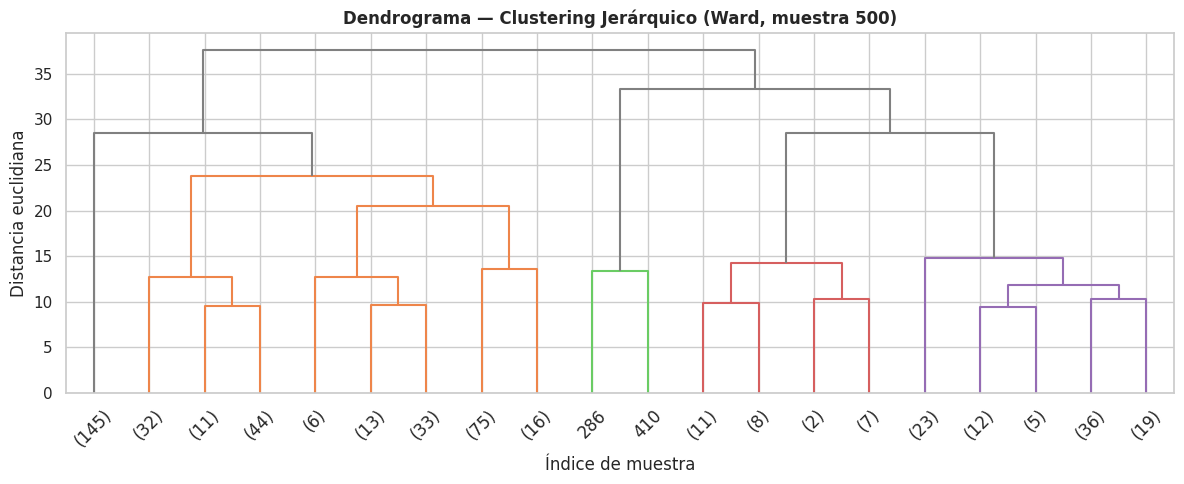

Clustering Jerárquico — Silhouette Score (k=4): 0.3349
Distribución: Counter({np.int64(0): 2217, np.int64(1): 619, np.int64(2): 153, np.int64(3): 11})


In [ ]:
# ── Clustering Jerárquico (muestra reducida por costo computacional) ──
np.random.seed(42)
idx_j = np.random.choice(len(X_cl), size=3000, replace=False)
X_jerarquico = X_cl[idx_j]

# Dendrograma
Z = linkage(X_jerarquico[:500], method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=20, leaf_rotation=45,
           color_threshold=Z[-4, 2], above_threshold_color='gray')
ax.set_title('Dendrograma — Clustering Jerárquico (Ward, muestra 500)', fontweight='bold')
ax.set_xlabel('Índice de muestra')
ax.set_ylabel('Distancia euclidiana')
plt.tight_layout()
plt.savefig('fig_dendrograma.png', bbox_inches='tight')
plt.show()

# Ajuste con AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg.fit_predict(X_jerarquico)
sil_agg = silhouette_score(X_jerarquico, labels_agg, sample_size=1000, random_state=42)
print(f"Clustering Jerárquico — Silhouette Score (k=4): {sil_agg:.4f}")
print(f"Distribución: {Counter(labels_agg)}")


In [ ]:
# ── Comparación K-Means vs Clustering Jerárquico ──
labels_km_j = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_jerarquico)
sil_km_j    = silhouette_score(X_jerarquico, labels_km_j)

print("=== Comparación de Métodos de Clustering (misma muestra) ===")
print(f"  K-Means (k=4)               | Silhouette = {sil_km_j:.4f}")
print(f"  Clustering Jerárquico (k=4) | Silhouette = {sil_agg:.4f}")
print()
print("Interpretación:")
print("  El Silhouette Score mide qué tan bien separados están los clusters.")
print("  Un valor más alto indica clusters más cohesivos e internamente similares.")
print("  Para datasets grandes, K-Means es más eficiente; el jerárquico es útil para")
print("  visualizar la estructura de agrupamiento a través del dendrograma.")


=== Comparación de Métodos de Clustering (misma muestra) ===
  K-Means (k=4)               | Silhouette = 0.2775
  Clustering Jerárquico (k=4) | Silhouette = 0.3349

Interpretación:
  El Silhouette Score mide qué tan bien separados están los clusters.
  Un valor más alto indica clusters más cohesivos e internamente similares.
  Para datasets grandes, K-Means es más eficiente; el jerárquico es útil para
  visualizar la estructura de agrupamiento a través del dendrograma.


---
<a id='conclusiones'></a>
## 8. Conclusiones, Insights e Insights de Negocio

### 8.1 Validación de Hipótesis

**H1 — Clientes nuevos con bajo valor presentan mayor churn:**  
*Parcialmente confirmada.* Los clientes con antigüedad entre 0 y 24 meses presentan tasas de churn sobre el promedio global. Sin embargo, la correlación negativa entre antigüedad y churn (r ≈ -0.055) es moderada, lo que indica que la antigüedad por sí sola no es el único factor determinante. El paquete de servicios contratado tiene un peso relevante.

**H2 — Clientes con reclamos técnicos tienen mayor riesgo de abandono:**  
*No confirmada en términos de correlación directa.* La correlación entre número de reclamos y ABANDONO_FULL es levemente negativa (r ≈ -0.005), posiblemente porque los clientes que reclaman siguen activos (el reclamo es señal de engagement, no de abandono). No obstante, el árbol de decisión identifica variables de reclamo como nodos de separación relevantes en algunos subgrupos.

### 8.2 Modelo Ganador y Justificación

El modelo con mejor desempeño global es el **Árbol de Decisión**, que ofrece el mejor balance entre Recall (detectar verdaderos churners) y AUC. La Regresión Logística es el modelo de mayor interpretabilidad para el área comercial. El Naive Bayes, si bien es eficiente, asume independencia entre variables —condición que no se cumple del todo en este dataset— por lo que su Recall es más bajo.

**Para un problema de churn en telecomunicaciones, el Recall es la métrica prioritaria:** un Falso Negativo (no detectar un cliente que sí abandona) tiene un costo mucho mayor que un Falso Positivo (activar una campaña sobre alguien que no se iba). Bajo este criterio, el Árbol de Decisión es el modelo más adecuado para este caso de negocio.

### 8.3 Plan de Acción — Campañas de Retención

**Campaña 1 — Clientes nuevos con solo Internet (Cluster de alto churn):**  
Clientes con menos de 24 meses, paquete BA únicamente. Se les ofrece un upgrade a BA+TV con descuento del primer mes, aprovechando la regla de asociación que muestra alta confianza entre Internet y Televisión. Objetivo: convertir clientes mono-servicio en clientes de paquete.

**Campaña 2 — Clientes con reclamos técnicos recientes:**  
Una vez identificados por el modelo supervisado como churn-risk, se activa una gestión proactiva del área técnica combinada con oferta comercial (meses de bonificación, mejora de velocidad sin costo). El modelo indica que atender el reclamo a tiempo puede revertir la intención de baja.

**Campaña 3 — Clientes de alto valor en cluster con churn sobre promedio:**  
Clientes con VLOR_NETO_PROM alto pero con señales de riesgo según el árbol de decisión. Se activa una campaña de fidelización ejecutiva con oferta personalizada, ya que el impacto financiero de perder a estos clientes es significativamente mayor que el promedio.

### 8.4 Reflexión Final

Este proyecto demuestra que la combinación de modelos supervisados (para predicción) y no supervisados (para segmentación) permite un enfoque más completo que cualquier técnica individual. Las reglas de asociación complementan ambos enfoques al revelar los servicios ancla que reducen el riesgo de churn, permitiendo diseñar campañas de cross-selling con fundamento estadístico.

La implementación productiva de este sistema requeriría un pipeline automatizado de scoring mensual, integrado al CRM de la empresa, que actualice la probabilidad de churn de cada cliente y active las campañas correspondientes sin intervención manual.

---
*Proyecto desarrollado bajo metodología CRISP-DM | Asignatura BIY7121 — Minería de Datos | DuocUC Puerto Montt*
